# sin(x) 的 9 点牛顿插值

区间：$[0,2\pi]$  
节点数：9

本 Notebook 包含：

1. 牛顿差商系数的计算；
2. 八次牛顿插值多项式的计算；
3. 牛顿插值曲线与原函数的比较；
4. 插值绝对误差；
5. 差商表输出；
6. 图片自动保存为 PNG 文件。

In [1]:
"""
============================================================
sin(x) 的 9 点牛顿插值
------------------------------------------------------------

区间：[0, 2π]
节点数：9

实现内容：

1. 计算牛顿差商系数
2. 构造八次牛顿插值多项式
3. 绘制牛顿插值曲线
4. 绘制牛顿插值误差
5. 输出差商表和最大误差

每张图都会：

- 在 Jupyter Notebook 中显示
- 自动保存为 PNG 文件

依赖库：

numpy
matplotlib

============================================================
"""

import os

import numpy as np
import matplotlib.pyplot as plt


# 如果 Figures 文件夹不存在，则自动创建
os.makedirs("Figures", exist_ok=True)


def divided_difference(x_nodes, y_nodes):
    """
    计算牛顿插值的差商表和差商系数。

    返回：
    table       完整差商表
    coefficients  牛顿插值多项式的系数
    """

    x_nodes = np.asarray(x_nodes, dtype=float)
    y_nodes = np.asarray(y_nodes, dtype=float)

    n = len(x_nodes)

    # 差商表第一列为函数值
    table = np.zeros((n, n), dtype=float)
    table[:, 0] = y_nodes

    # 逐阶计算差商
    for j in range(1, n):
        for i in range(n - j):
            table[i, j] = (
                table[i + 1, j - 1] - table[i, j - 1]
            ) / (
                x_nodes[i + j] - x_nodes[i]
            )

    # 牛顿插值系数位于差商表第一行
    coefficients = table[0, :].copy()

    return table, coefficients


def newton_interpolation(x_nodes, coefficients, x):
    """
    根据牛顿差商系数计算插值多项式。

    采用嵌套乘法形式计算，避免直接展开高次多项式。
    """

    x_nodes = np.asarray(x_nodes, dtype=float)
    coefficients = np.asarray(coefficients, dtype=float)
    x = np.asarray(x, dtype=float)

    # 从最高阶系数开始进行嵌套计算
    y = np.full_like(x, coefficients[-1], dtype=float)

    for k in range(len(coefficients) - 2, -1, -1):
        y = coefficients[k] + (x - x_nodes[k]) * y

    return y


In [2]:
# 在区间 [0, 2π] 上构造 9 个等距插值节点
x_nodes = np.linspace(
    0.0,
    2.0 * np.pi,
    9
)

# 节点对应的函数值
y_nodes = np.sin(x_nodes)


# 构造致密网格，用于绘图和误差计算
x = np.linspace(
    0.0,
    2.0 * np.pi,
    2000
)

# 原函数真值
y_true = np.sin(x)


# 计算差商表和牛顿插值系数
difference_table, coefficients = divided_difference(
    x_nodes,
    y_nodes
)

# 计算牛顿插值结果
y_newton = newton_interpolation(
    x_nodes,
    coefficients,
    x
)

# 计算绝对误差
error_newton = np.abs(
    y_newton - y_true
)


print("牛顿插值系数：")
for i, value in enumerate(coefficients):
    print(f"a[{i}] = {value:.12e}")

print()
print(
    "牛顿插值最大绝对误差：",
    np.max(error_newton)
)


牛顿插值系数：
a[0] = 0.000000000000e+00
a[1] = 9.003163161571e-01
a[2] = -3.357488673628e-01
a[3] = -5.902387726988e-02
a[4] = 3.757576731180e-02
a[5] = -2.802575292443e-03
a[6] = -8.410680876818e-04
a[7] = 1.529830212930e-04
a[8] = -8.066999314150e-19

牛顿插值最大绝对误差： 0.0012055371435693574


/tmp/ipykernel_518755/3874391182.py:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/tmp/ipykernel_518755/3874391182.py:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/tmp/ipykernel_518755/3874391182.py:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/tmp/ipykernel_518755/3874391182.py:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:1

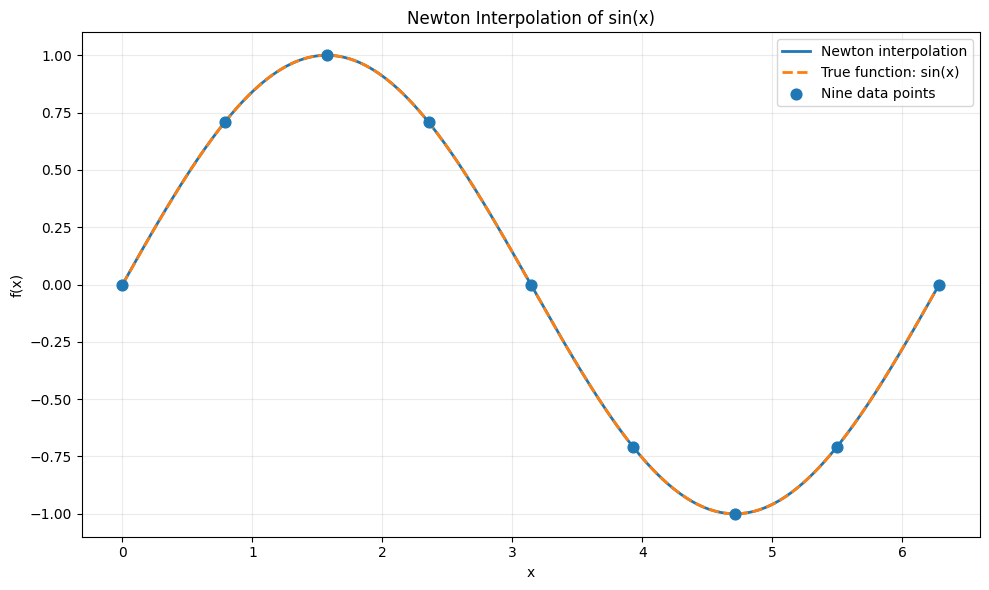

/tmp/ipykernel_518755/3874391182.py:67: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/tmp/ipykernel_518755/3874391182.py:67: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/tmp/ipykernel_518755/3874391182.py:67: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/tmp/ipykernel_518755/3874391182.py:67: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:1

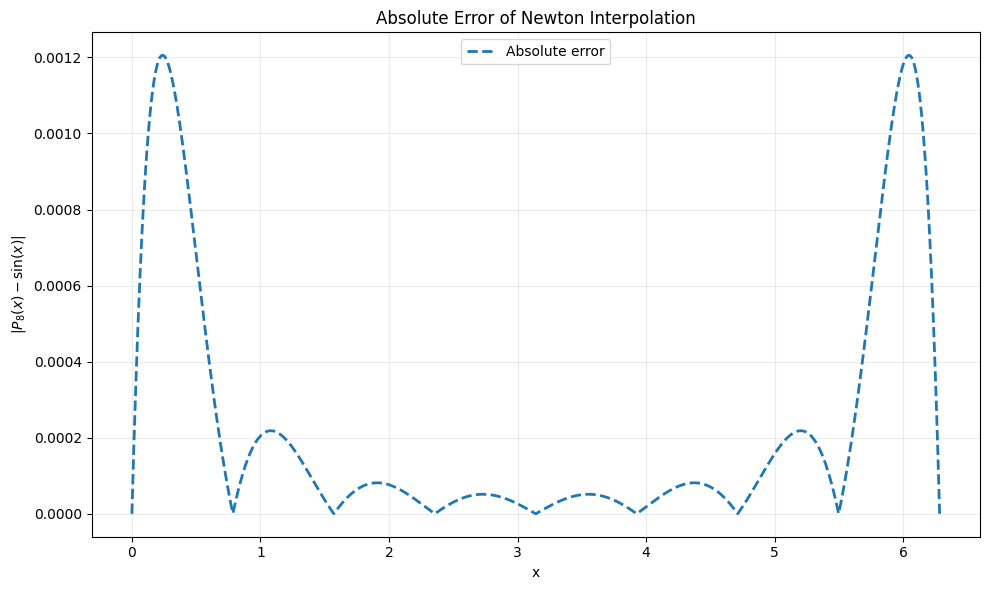

In [3]:
# ==========================================================
# 牛顿插值曲线
# ==========================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    x_nodes,
    y_nodes,
    s=60,
    label="Nine data points",
    zorder=3
)

plt.plot(
    x,
    y_newton,
    linewidth=2,
    label="Newton interpolation"
)

plt.plot(
    x,
    y_true,
    "--",
    linewidth=2,
    label="True function: sin(x)"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Newton Interpolation of sin(x)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig(
    "Figures/newton_interpolation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================================
# 牛顿插值误差
# ==========================================================

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    error_newton,
    "--",
    linewidth=2,
    label="Absolute error"
)

plt.xlabel("x")
plt.ylabel(r"$|P_8(x)-\sin(x)|$")
plt.title("Absolute Error of Newton Interpolation")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig(
    "Figures/newton_interpolation_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [4]:
# 输出完整差商表

np.set_printoptions(
    precision=8,
    suppress=True
)

print("牛顿差商表：")
print(difference_table)


牛顿差商表：
[[ 0.          0.90031632 -0.33574887 -0.05902388  0.03757577 -0.00280258
  -0.00084107  0.00015298 -0.        ]
 [ 0.70710678  0.37292323 -0.4748206   0.05902388  0.02657008 -0.00676602
   0.          0.00015298  0.        ]
 [ 1.         -0.37292323 -0.33574887  0.14249625 -0.         -0.00676602
   0.00084107  0.          0.        ]
 [ 0.70710678 -0.90031632  0.          0.14249625 -0.02657008 -0.00280258
   0.          0.          0.        ]
 [ 0.         -0.90031632  0.33574887  0.05902388 -0.03757577  0.
   0.          0.          0.        ]
 [-0.70710678 -0.37292323  0.4748206  -0.05902388  0.          0.
   0.          0.          0.        ]
 [-1.          0.37292323  0.33574887  0.          0.          0.
   0.          0.          0.        ]
 [-0.70710678  0.90031632  0.          0.          0.          0.
   0.          0.          0.        ]
 [-0.          0.          0.          0.          0.          0.
   0.          0.          0.        ]]
